In [9]:
import numpy as np

# 数据集
x = np.array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
y = np.array([1, 1, 1, -1, -1, -1, 1, 1, 1, -1])
n = len(y)

# 初始化样本权重
D = np.ones(n) / n

# 定义弱分类器
G_list = [
    lambda x: 1 if x < 2.5 else -1,  # G1(x)
    lambda x: 1 if x < 8.5 else -1,  # G2(x)
    lambda x: 1 if x >= 5.5 else -1  # G3(x)
]

# 计算每个弱分类器的误差和权重
alpha_list = []
for G in G_list:
    pred = np.array([G(xi) for xi in x])
    error = sum(D[i] for i in range(n) if pred[i] != y[i])
    
    # 避免除零错误
    if error == 0:
        error = 1e-10
    
    # 计算学习器权重
    alpha = 0.5 * np.log((1 - error) / error)
    alpha_list.append(alpha)
    
    # 更新样本权重
    D = D * np.exp(-alpha * y * pred)
    D = D / np.sum(D)  # 归一化
    
    print(f"当前分类器误差: {error:.4f}, 权重: {alpha:.4f}")
    print(f"更新后的样本权重: {np.round(D, 4)}")
    print("-" * 50)

# 输出最终学习器权重（保留四位小数）
print("最终学习器权重:", [round(alpha.item(), 4) for alpha in alpha_list])

# 公式说明
print("\n计算公式:")
print("1. 学习器权重计算: α_t = 0.5 * ln((1 - ε_t) / ε_t)")
print("2. 样本权重更新: D_i^{(t+1)} = D_i^{(t)} * exp(-α_t * y_i * G_t(x_i))")
print("3. 归一化: D_i^{(t+1)} = D_i^{(t+1)} / sum(D^{(t+1)})")

当前分类器误差: 0.3000, 权重: 0.4236
更新后的样本权重: [0.0714 0.0714 0.0714 0.0714 0.0714 0.0714 0.1667 0.1667 0.1667 0.0714]
--------------------------------------------------
当前分类器误差: 0.2143, 权重: 0.6496
更新后的样本权重: [0.0455 0.0455 0.0455 0.1667 0.1667 0.1667 0.1061 0.1061 0.1061 0.0455]
--------------------------------------------------
当前分类器误差: 0.1818, 权重: 0.7520
更新后的样本权重: [0.125  0.125  0.125  0.1019 0.1019 0.1019 0.0648 0.0648 0.0648 0.125 ]
--------------------------------------------------
最终学习器权重: [0.4236, 0.6496, 0.752]

计算公式:
1. 学习器权重计算: α_t = 0.5 * ln((1 - ε_t) / ε_t)
2. 样本权重更新: D_i^{(t+1)} = D_i^{(t)} * exp(-α_t * y_i * G_t(x_i))
3. 归一化: D_i^{(t+1)} = D_i^{(t+1)} / sum(D^{(t+1)})


Accuracy: 1.0


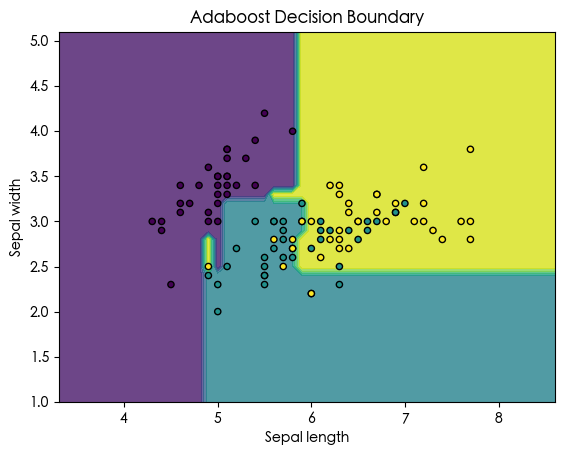

In [10]:
# 导入必要的库
import numpy as np
import pandas as pd
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

from matplotlib import rcParams

# 配置 matplotlib 使用字体
rcParams['font.sans-serif'] = ['Heiti TC']
rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

# 加载 iris 数据集
iris = datasets.load_iris()
X = iris.data
y = iris.target

# 将数据集分为训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 创建一个决策树桩作为弱分类器
dt_stump = DecisionTreeClassifier(max_depth=1, min_samples_leaf=1)

# 创建 Adaboost 分类器，使用决策树桩作为基分类器
ada = AdaBoostClassifier(estimator=dt_stump, n_estimators=50, learning_rate=1, random_state=42)

# 训练 Adaboost 模型
ada.fit(X_train, y_train)

# 在测试集上进行预测
y_pred = ada.predict(X_test)

# 计算准确率
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# 绘制分类决策边界（仅适用于二维数据，这里为了简化，我们使用前两个特征）
X_train_2d = X_train[:, :2]
X_test_2d = X_test[:, :2]
ada_2d = AdaBoostClassifier(estimator=dt_stump, n_estimators=50, learning_rate=1, random_state=42)
ada_2d.fit(X_train_2d, y_train)

# 创建网格点以绘制决策边界
x_min, x_max = X_train_2d[:, 0].min() - 1, X_train_2d[:, 0].max() + 1
y_min, y_max = X_train_2d[:, 1].min() - 1, X_train_2d[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1), np.arange(y_min, y_max, 0.1))

# 预测网格点的类别
Z = ada_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# 绘制决策边界和数据点
plt.contourf(xx, yy, Z, alpha=0.8)
plt.scatter(X_train_2d[:, 0], X_train_2d[:, 1], c=y_train, edgecolor='k', s=20)
plt.xlabel('Sepal length')
plt.ylabel('Sepal width')
plt.title('Adaboost Decision Boundary')
plt.show()